<a href="https://colab.research.google.com/github/arxsyy/MachineLearning_2026/blob/main/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

In [5]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

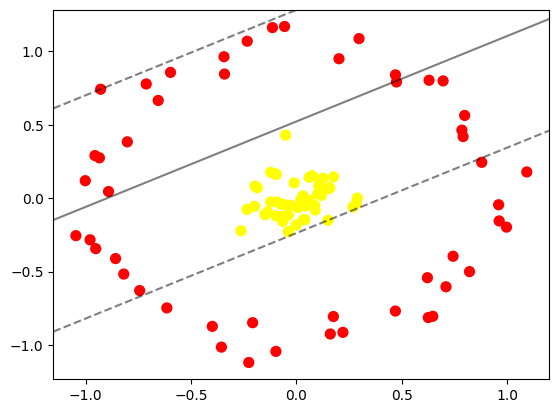

In [6]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [7]:
r = np.exp(-(X**2).sum(1))

In [8]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 2.88610090e-01,  1.00517791e-03],
       [ 4.69449871e-01, -7.69163630e-01],
       [-3.41251430e-01,  8.45951525e-01],
       [ 6.46787562e-01, -8.04826665e-01],
       [ 6.95715508e-01,  7.99312318e-01],
       [-6.55627257e-01,  6.66082174e-01],
       [ 3.25626437e-02, -1.47210104e-01],
       [ 4.69774812e-01,  8.40612194e-01],
       [-9.72097101e-02, -1.04404114e+00],
       [-8.57796547e-01, -4.11426500e-01],
       [-6.53029617e-02, -1.58180029e-01],
       [-3.86361497e-02, -2.27752340e-01],
       [ 7.98041911e-01,  5.64137860e-01],
       [-6.12485842e-02, -1.27516844e-01],
       [-1.98918296e-01, -5.53686975e-02],
       [-1.85315865e-01,  7.13352643e-02],
       [ 6.19406982e-02, -1.43465743e-02],
       [ 1.01071968e-01,  3.13659980e-02],
       [-6.14650549e-01, -7.47753657e-01],
       [-8.02201506e-01,  3.84080421e-01],
       [-1.96573233e-01,  8.28804442e-02],
       [ 7.14098732e-03, -6.42030913e-02],
       [ 9.59114313e-01, -4.47143529e-02],
       [-3.43626330e-01,  9.64126793e-01],
       [-3.99043423e-01, -8.73518374e-01],
       [-3.86304139e-02, -4.94325159e-02],
       [ 7.43012338e-01, -3.95694755e-01],
       [-1.00153774e+00,  1.19308191e-01],
       [ 6.06776733e-02,  1.41856768e-01],
       [-9.78778848e-01, -2.83533944e-01],
       [-9.27273527e-02, -2.56746396e-02],
       [-1.22806005e-01, -2.47449798e-02],
       [ 1.58625445e-01,  7.15436953e-02],
       [ 2.01783572e-01,  9.50426500e-01],
       [-3.55743536e-01, -1.01486927e+00],
       [ 9.61634917e-01, -1.55025657e-01],
       [ 1.11863538e-01,  8.55663237e-02],
       [-5.10089909e-02,  4.29265185e-01],
       [-1.22118542e-01,  1.76062026e-01],
       [ 1.11411149e-01,  1.03840018e-01],
       [ 9.96505773e-01, -1.97176494e-01],
       [ 2.84779131e-01, -3.34481363e-02],
       [ 6.29281557e-01,  8.03767228e-01],
       [ 1.06192007e-01,  8.47761086e-02],
       [ 8.21030787e-01, -5.00368179e-01],
       [-8.18949751e-01, -5.17096628e-01],
       [-7.12381023e-01,  7.78327102e-01],
       [-5.63406906e-02,  1.17023997e+00],
       [-1.48749964e-01, -1.11147083e-01],
       [-1.36949020e-01, -9.41789927e-02],
       [-3.82830599e-02, -1.14323217e-01],
       [ 8.90030949e-02, -8.09795828e-02],
       [ 1.18849600e-01,  2.01521328e-02],
       [-1.07754308e-02,  1.03956692e-01],
       [-9.77578388e-02, -1.20841729e-01],
       [ 1.25817014e-01,  1.35466377e-01],
       [ 4.31249418e-02, -5.24713262e-02],
       [ 2.20569416e-01, -9.14319708e-01],
       [ 7.90552844e-01,  4.20059145e-01],
       [-9.94682366e-02,  1.66251892e-01],
       [-5.97249589e-01,  8.57307746e-01],
       [ 8.59873776e-02, -4.85587355e-02],
       [ 7.51395302e-02,  1.53238499e-01],
       [-9.52008367e-01, -3.43922983e-01],
       [ 8.78963470e-01,  2.44482646e-01],
       [ 1.75329585e-01, -8.06467763e-01],
       [ 2.08983307e-02, -1.22093198e-02],
       [-7.43387232e-01, -6.29447496e-01],
       [ 6.25485138e-01, -8.13483207e-01],
       [ 3.05474433e-02,  1.66935357e-02],
       [ 1.52980611e-01,  6.56132756e-02],
       [ 1.75478816e-01,  1.45321891e-01],
       [-8.91198298e-01,  4.54812962e-02],
       [-2.62909185e-01, -2.22180604e-01],
       [-2.33444444e-01,  1.06995671e+00],
       [-1.04601547e+00, -2.55276924e-01],
       [-7.04665055e-02, -4.30565292e-02],
       [ 1.49552626e-01, -1.50577044e-01],
       [-7.46109172e-02, -1.25869087e-01],
       [-2.07719165e-01, -8.48451843e-01],
       [ 7.84786435e-01,  4.63843533e-01],
       [-2.34201930e-01, -7.68787237e-02],
       [ 2.96856597e-01,  1.08758198e+00],
       [ 7.09379667e-01, -6.03606680e-01],
       [ 6.21246975e-01, -5.41853084e-01],
       [-2.25922296e-01, -1.11956453e+00],
       [-9.34585564e-01,  2.75069519e-01],
       [-9.28722789e-01,  7.42699767e-01],
       [-1.13753031e-01,  1.16271809e+00],
       [-6.58971287e-02, -3.98296526e-02],
       [-2.84429218e-02, -4.87204185e-02],
       [ 4.74488474e-01,  7.92211629e-01

In [9]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

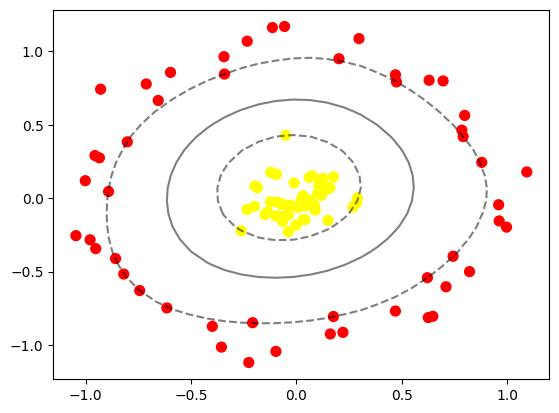

In [10]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')